<a href="https://colab.research.google.com/github/Raka7317/DATA-STRUCTURE-/blob/main/text_speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# STEP 1: Install Libraries and Load Dataset
# Copy-paste this entire block into a Colab cell and run it
# ============================================================

# Install required libraries
!pip install transformers datasets torch scikit-learn matplotlib seaborn -q

# Import libraries
import pandas as pd
from datasets import load_dataset

print("Loading IMDB dataset... (this may take 1-2 minutes)")

# Load the IMDB dataset from HuggingFace (free, no download needed)
dataset = load_dataset("imdb")

# Use a small subset so it runs faster (500 train, 200 test)
train_data = dataset["train"].shuffle(seed=42).select(range(500))
test_data  = dataset["test"].shuffle(seed=42).select(range(200))

# Convert to pandas DataFrame for easy viewing
train_df = pd.DataFrame(train_data)
test_df  = pd.DataFrame(test_data)

# Label: 0 = Negative, 1 = Positive
train_df["sentiment"] = train_df["label"].map({0: "Negative", 1: "Positive"})
test_df["sentiment"]  = test_df["label"].map({0: "Negative", 1: "Positive"})

print("\n Dataset loaded successfully!")
print(f"Training samples : {len(train_df)}")
print(f"Testing samples  : {len(test_df)}")
print("\nSample reviews:")
print(train_df[["text", "sentiment"]].head(3).to_string(index=False))

Loading IMDB dataset... (this may take 1-2 minutes)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


 Dataset loaded successfully!
Training samples : 500
Testing samples  : 200

Sample reviews:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [3]:
# ============================================================
# STEP 2 (FIXED): Fine-tune BERT and Evaluate
# Fix: replaced evaluation_strategy with eval_strategy
# Run this AFTER Step 1 completes successfully
# ============================================================

import torch
import numpy as np
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score

# ----------------------------
# 1. Load BERT tokenizer
# ----------------------------
print("Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# ----------------------------
# 2. Tokenize the text data
# ----------------------------
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

print("Tokenizing data...")
train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
test_dataset  = Dataset.from_pandas(test_df[["text", "label"]])

train_tokenized = train_dataset.map(tokenize, batched=True)
test_tokenized  = test_dataset.map(tokenize, batched=True)

train_tokenized = train_tokenized.rename_column("label", "labels")
test_tokenized  = test_tokenized.rename_column("label", "labels")
train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_tokenized.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

# ----------------------------
# 3. Load BERT model
# ----------------------------
print("Loading BERT model (2 labels: Positive / Negative)...")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

# ----------------------------
# 4. Define metrics
# ----------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    acc    = accuracy_score(labels, preds)
    f1     = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

# ----------------------------
# 5. Training configuration (FIXED)
# ----------------------------
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",        # FIXED: was evaluation_strategy
    save_strategy="no",
    logging_dir="./logs",
    logging_steps=20,
    load_best_model_at_end=False,
    report_to="none",
)

# ----------------------------
# 6. Train the model
# ----------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

print("\nTraining started... (takes ~5-10 minutes on Colab GPU)")
print("Tip: Go to Runtime > Change runtime type > GPU for faster training\n")
trainer.train()

# ----------------------------
# 7. Evaluate
# ----------------------------
results = trainer.evaluate()
print("\n===== EVALUATION RESULTS =====")
print(f"Accuracy : {results['eval_accuracy']*100:.2f}%")
print(f"F1 Score : {results['eval_f1']:.4f}")

# Save predictions for Step 3
predictions = trainer.predict(test_tokenized)
pred_labels = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

import pickle
with open("predictions.pkl", "wb") as f:
    pickle.dump({
        "pred": pred_labels,
        "true": true_labels,
        "texts": test_df["text"].tolist()
    }, f)

print("\nPredictions saved. Run Step 3 next!")

Loading BERT tokenizer...
Tokenizing data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading BERT model (2 labels: Positive / Negative)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 


Training started... (takes ~5-10 minutes on Colab GPU)
Tip: Go to Runtime > Change runtime type > GPU for faster training



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.492508,0.520669,0.755000,0.750574
2,0.176453,0.456631,0.850000,0.850045



===== EVALUATION RESULTS =====
Accuracy : 85.00%
F1 Score : 0.8500

Predictions saved. Run Step 3 next!


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85       104
    Positive       0.84      0.85      0.85        96

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



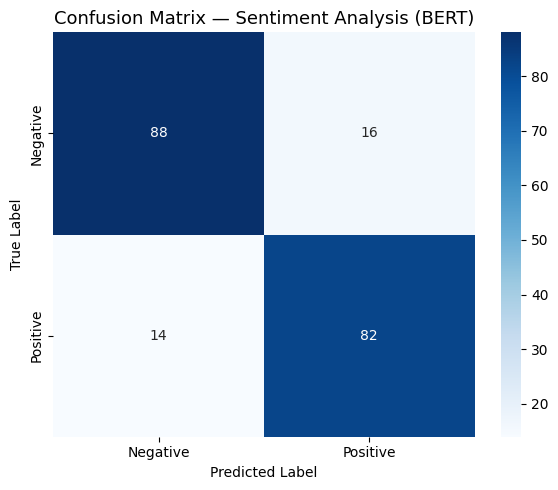

Confusion matrix saved as confusion_matrix.png


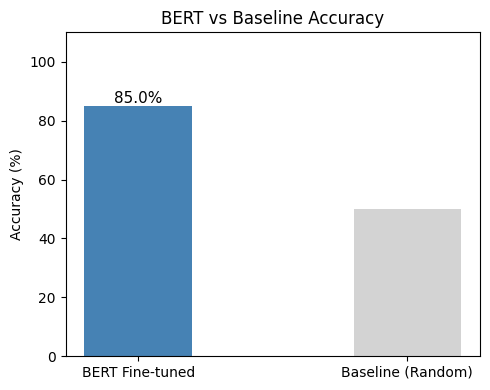

Accuracy chart saved as accuracy_chart.png

===== SAMPLE PREDICTIONS =====
✓ Actual: Positive | Predicted: Positive | Review: <br /><br />When I unsuspectedly rented A Thousand Acres, I thought I was in for an entertaining King Lear story and of ...
✓ Actual: Positive | Predicted: Positive | Review: This is the latest entry in the long series of films with the French agent, O.S.S. 117 (the French answer to James Bond)...
✓ Actual: Negative | Predicted: Negative | Review: This movie was so frustrating. Everything seemed energetic and I was totally prepared to have a good time. I at least th...
✓ Actual: Positive | Predicted: Positive | Review: I was truly and wonderfully surprised at "O' Brother, Where Art Thou?" The video store was out of all the movies I was p...
✓ Actual: Negative | Predicted: Negative | Review: This movie spends most of its time preaching that it is the script that makes the movie, but apparently there was no scr...
✓ Actual: Positive | Predicted: Positive | Review:

In [4]:
# ============================================================
# STEP 3: Visualize Results
# Run this AFTER Step 2 completes successfully
# ============================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
)

# ----------------------------
# 1. Load saved predictions
# ----------------------------
with open("predictions.pkl", "rb") as f:
    data = pickle.load(f)

pred_labels = data["pred"]
true_labels = data["true"]
texts       = data["texts"]

label_names = ["Negative", "Positive"]

# ----------------------------
# 2. Print classification report
# ----------------------------
print("===== CLASSIFICATION REPORT =====")
print(classification_report(true_labels, pred_labels, target_names=label_names))

# ----------------------------
# 3. Confusion Matrix
# ----------------------------
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Confusion Matrix — Sentiment Analysis (BERT)", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

# ----------------------------
# 4. Accuracy Bar Chart
# ----------------------------
acc = accuracy_score(true_labels, pred_labels)

plt.figure(figsize=(5, 4))
bars = plt.bar(
    ["BERT Fine-tuned"],
    [acc * 100],
    color=["steelblue"],
    width=0.4,
)
plt.bar(["Baseline (Random)"], [50], color=["lightgray"], width=0.4)
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("BERT vs Baseline Accuracy")
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha="center", fontsize=11
    )
plt.tight_layout()
plt.savefig("accuracy_chart.png", dpi=150)
plt.show()
print("Accuracy chart saved as accuracy_chart.png")

# ----------------------------
# 5. Sample Predictions
# ----------------------------
print("\n===== SAMPLE PREDICTIONS =====")
label_map = {0: "Negative", 1: "Positive"}
for i in range(10):
    review   = texts[i][:120].replace("\n", " ")
    actual   = label_map[true_labels[i]]
    predicted = label_map[pred_labels[i]]
    correct  = "✓" if actual == predicted else "✗"
    print(f"{correct} Actual: {actual:8s} | Predicted: {predicted:8s} | Review: {review}...")

print("\nAll done! Your case study is complete.")
print("Files generated:")
print("  - confusion_matrix.png")
print("  - accuracy_chart.png")